In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
!ls "/content/drive/MyDrive/AML"

'APPLIED MACHINE LEARNING (EEEM068) - SEMR2 20256 - 4292026 - 506 PM.zip'
 dev.zip
'EEEM068_AssessmentGuidance (1).pdf'
 english_train.txt
'Human Sentiment Analysis.pdf'
 image_index_train.txt
 README.md
 sentiment_dev.txt
 sentiment_test.txt
 sentiment_train.txt
 test.zip
 train_ende.zip


In [22]:
!unzip "/content/drive/MyDrive/AML/train_ende.zip" -d /content/dataset/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train_ende/5499.jpg  
  inflating: /content/dataset/train_ende/55.jpg  
  inflating: /content/dataset/train_ende/550.jpg  
  inflating: /content/dataset/train_ende/5500.jpg  
  inflating: /content/dataset/train_ende/5501.jpg  
  inflating: /content/dataset/train_ende/5502.jpg  
  inflating: /content/dataset/train_ende/5503.jpg  
  inflating: /content/dataset/train_ende/5504.jpg  
  inflating: /content/dataset/train_ende/5505.jpg  
  inflating: /content/dataset/train_ende/5506.jpg  
  inflating: /content/dataset/train_ende/5507.jpg  
  inflating: /content/dataset/train_ende/5508.jpg  
  inflating: /content/dataset/train_ende/5509.jpg  
  inflating: /content/dataset/train_ende/551.jpg  
  inflating: /content/dataset/train_ende/5510.jpg  
  inflating: /content/dataset/train_ende/5511.jpg  
  inflating: /content/dataset/train_ende/5512.jpg  
  inflating: /content/dataset/train_ende/5513.jpg  
  inflating: /con

In [4]:
pip install torch torchvision facenet-pytorch matplotlib pandas pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 740.1 kB/s eta 0:00:00
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 8.6 MB/s eta 0:00:00


In [23]:
!unzip "/content/drive/MyDrive/AML/dev.zip" -d /content/dataset/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/dev/1054.jpg  
  inflating: /content/dataset/dev/1055.jpg  
  inflating: /content/dataset/dev/1056.jpg  
  inflating: /content/dataset/dev/1057.jpg  
  inflating: /content/dataset/dev/1058.jpg  
  inflating: /content/dataset/dev/1059.jpg  
  inflating: /content/dataset/dev/106.jpg  
  inflating: /content/dataset/dev/1060.jpg  
  inflating: /content/dataset/dev/1061.jpg  
  inflating: /content/dataset/dev/1062.jpg  
  inflating: /content/dataset/dev/1063.jpg  
  inflating: /content/dataset/dev/1064.jpg  
  inflating: /content/dataset/dev/1065.jpg  
  inflating: /content/dataset/dev/1066.jpg  
  inflating: /content/dataset/dev/1067.jpg  
  inflating: /content/dataset/dev/1068.jpg  
  inflating: /content/dataset/dev/1069.jpg  
  inflating: /content/dataset/dev/107.jpg  
  inflating: /content/dataset/dev/1070.jpg  
  inflating: /content/dataset/dev/1071.jpg  
  inflating: /content/dataset/dev/1072.jpg  
  infl

In [24]:
!unzip "/content/drive/MyDrive/AML/test.zip" -d /content/dataset/

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/test/1058.jpg  
  inflating: /content/dataset/test/1059.jpg  
  inflating: /content/dataset/test/106.jpg  
  inflating: /content/dataset/test/1060.jpg  
  inflating: /content/dataset/test/1061.jpg  
  inflating: /content/dataset/test/1062.jpg  
  inflating: /content/dataset/test/1063.jpg  
  inflating: /content/dataset/test/1064.jpg  
  inflating: /content/dataset/test/1065.jpg  
  inflating: /content/dataset/test/1066.jpg  
  inflating: /content/dataset/test/1067.jpg  
  inflating: /content/dataset/test/1068.jpg  
  inflating: /content/dataset/test/1069.jpg  
  inflating: /content/dataset/test/107.jpg  
  inflating: /content/dataset/test/1070.jpg  
  inflating: /content/dataset/test/1071.jpg  
  inflating: /content/dataset/test/1072.jpg  
  inflating: /content/dataset/test/1073.jpg  
  inflating: /content/dataset/test/1074.jpg  
  inflating: /content/dataset/test/1075.jpg  
  inflating: /content/dataset/t

In [25]:
import os
os.makedirs(image_folder, exist_ok=True)
image_folder = '/content/dataset/train_ende'
sentiment_file = '/content/drive/MyDrive/AML/sentiment_train.txt'
all_files = os.listdir(image_folder)
image_count = len([f for f in all_files if f.lower().endswith('.jpg')])

# --- COUNT LABELS ---
# We open the file and count every line
with open(sentiment_file, 'r') as f:
    label_count = len(f.readlines())

# --- THE COMPARISON ---
print(f"Total Images found: {image_count}")
print(f"Total Labels found: {label_count}")

if image_count == label_count:
    print(" The counts match! ")
else:
    print("The counts do NOT match.")

Total Images found: 20240
Total Labels found: 20240
 The counts match! 


--- Sentiment Distribution ---
Neutral (0): 6922 images (34.20%)
Negative (1): 7835 images (38.71%)
Positive (2): 5483 images (27.09%)


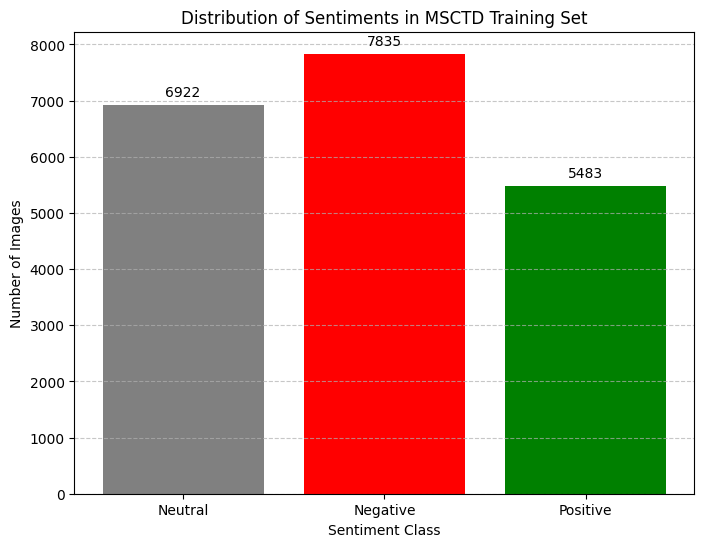

In [26]:
import matplotlib.pyplot as plt
from collections import Counter
sentiment_file = '/content/drive/MyDrive/AML/sentiment_train.txt'

# Read the file and store labels as integers
with open(sentiment_file, 'r') as f:
    # We strip whitespace and ignore empty lines
    labels = [line.strip() for line in f.readlines() if line.strip()]

#  Count
counts = Counter(labels)
label_map = {
    '0': 'Neutral',
    '1': 'Negative',
    '2': 'Positive'
}

print("--- Sentiment Distribution ---")
for key in sorted(label_map.keys()):
    name = label_map[key]
    count = counts.get(key, 0)
    percentage = (count / len(labels)) * 100
    print(f"{name} ({key}): {count} images ({percentage:.2f}%)")

# Bar Chart
names = [label_map[k] for k in sorted(label_map.keys())]
values = [counts.get(k, 0) for k in sorted(label_map.keys())]

plt.figure(figsize=(8, 6))
bars = plt.bar(names, values, color=['gray', 'red', 'green'])

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, yval, ha='center', va='bottom')

plt.title('Distribution of Sentiments in MSCTD Training Set')
plt.xlabel('Sentiment Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**1. The Face Extraction**

1.   Loops through image folder.
2. Uses MTCNN (from facenet-pytorch) to detect the face.
3. Crops the face and resizes it to 224 × 224
4. Saves the face to a new folder called /train_faces/.

In [27]:
import os
import torch
from PIL import Image
from facenet_pytorch import MTCNN
from tqdm import tqdm

In [28]:
input_dir = '/content/dataset/train_ende'
output_dir = './train_faces/'
os.makedirs(output_dir, exist_ok=True)

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

Running on: cpu


In [30]:
mtcnn = MTCNN(
    image_size=224,
    margin=20,
    post_process=False,
    device=device,
    select_largest=True
)

In [31]:
image_files = [f for f in os.listdir(input_dir) if f.lower().endswith('.jpg')]
image_files.sort(key=lambda x: int(x.split('.')[0])) # Sorts 0.jpg, 1.jpg, 2.jpg...

print(f"Starting extraction for {len(image_files)} images...")

Starting extraction for 20240 images...


In [ ]:
no_face_count = 0

for filename in tqdm(image_files):
    img_path = os.path.join(input_dir, filename)
    save_path = os.path.join(output_dir, filename)

    try:
        # Open image
        img = Image.open(img_path).convert('RGB')

        # Detect and Save face
        # If a face is found, mtcnn saves it to save_path and returns a tensor
        face = mtcnn(img, save_path=save_path)

        # 5. Handling "No Face" (Project Requirement 1.iii)
        if face is None:
            no_face_count += 1
            # LOGIC: If no face is found, we resize the original image to 224x224
            # and save it as a placeholder so our index stays consistent.
            img_resized = img.resize((224, 224))
            img_resized.save(save_path)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

print(f"\nExtraction Finished!")
print(f"Faces saved to: {output_dir}")
print(f"Images where no face was detected: {no_face_count}")

In [18]:
!zip -r /content/train_faces_processed.zip /content/train_faces

  adding: content/train_faces/ (stored 0%)


In [19]:
import shutil

# Create a folder in your Drive if it doesn't exist
import os
if not os.path.exists('/content/drive/MyDrive'):
    os.makedirs('/content/drive/MyDrive')

# Copy the file
shutil.copy('/content/train_faces_processed.zip', '/content/drive/MyDrive')

print("✅ Success! Your processed faces are now safe in your Google Drive.")

✅ Success! Your processed faces are now safe in your Google Drive.


In [20]:
# Change these to your actual folder names
dev_input = '/content/dataset/dev'
dev_output = './dev_faces/'
os.makedirs(dev_output, exist_ok=True)

dev_images = sorted([f for f in os.listdir(dev_input) if f.endswith('.jpg')], key=lambda x: int(x.split('.')[0]))

print(f"Processing Dev Set: {len(dev_images)} images")

for filename in tqdm(dev_images):
    img = Image.open(os.path.join(dev_input, filename)).convert('RGB')
    save_path = os.path.join(dev_output, filename)

    # Detect face
    face = mtcnn(img, save_path=save_path)

    # Simple Fallback if no face
    if face is None:
        img.resize((224, 224)).save(save_path)

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/dev'

In [ ]:
# Change these to your actual folder names
test_input = '/content/dataset/test'
test_output = './test_faces/'
os.makedirs(test_output, exist_ok=True)

test_images = sorted([f for f in os.listdir(test_input) if f.endswith('.jpg')], key=lambda x: int(x.split('.')[0]))

print(f"Processing Test Set: {len(test_images)} images")

for filename in tqdm(test_images):
    img = Image.open(os.path.join(test_input, filename)).convert('RGB')
    save_path = os.path.join(test_output, filename)

    # Detect face
    face = mtcnn(img, save_path=save_path)

    # Simple Fallback if no face
    if face is None:
        img.resize((224, 224)).save(save_path)

In [ ]:
!zip -r /content/dev_faces.zip /content/dev_faces
!zip -r /content/test_faces.zip /content/test_faces

In [ ]:
import shutil
shutil.copy('/content/dev_faces.zip', '/content/drive/MyDrive')
shutil.copy('/content/test_faces.zip', '/content/drive/MyDrive')

print("Done! Everything is saved to your Drive.")